# Customer Segmentation Analysis (RFM + K-Means)

**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** [UCI Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail) — 541,909 invoice-line transactions from a UK-based online retailer, December 2010 to December 2011.

**Tech Stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_excel('Online_Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Load & Inspect

In [2]:
print("Shape (rows, columns):", df.shape)
print("\nNull values per column:")
print(df.isnull().sum())
print("\nRows with negative Quantity (returns/cancellations):", (df['Quantity'] < 0).sum())
print("Rows with UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())

Shape (rows, columns): (541909, 8)

Null values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Rows with negative Quantity (returns/cancellations): 10624
Rows with UnitPrice <= 0: 2517


**Observation:** ~135,000 rows are missing a `CustomerID` — these can't be tied to any customer, so they're useless for segmentation and must be dropped. There are also ~10,600 rows with negative quantities (order cancellations/returns, flagged with an InvoiceNo starting with 'C') and a small number of rows with zero or negative price, which are data entry issues rather than real sales.

## 2. Data Cleaning

In [3]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Unique customers remaining: {df_clean['CustomerID'].nunique():,}")

Rows before cleaning: 541,909
Rows after cleaning: 397,884
Unique customers remaining: 4,338


**Observation:** After removing missing customer IDs, cancelled orders, and invalid prices, we're left with a clean set of genuine purchase transactions across roughly 4,300 unique customers — this is our working base for segmentation.

## 3. Descriptive Statistics

In [4]:
customer_txn = df_clean.groupby('CustomerID').agg(
    total_spend=('TotalPrice', 'sum'),
    num_invoices=('InvoiceNo', 'nunique'),
    avg_purchase_value=('TotalPrice', 'mean')
)

print("Average purchase value per transaction line: £{:.2f}".format(df_clean['TotalPrice'].mean()))
print("Average number of invoices (purchase frequency) per customer: {:.2f}".format(customer_txn['num_invoices'].mean()))
print("Average customer lifetime value (total spend per customer): £{:.2f}".format(customer_txn['total_spend'].mean()))
print("Median customer lifetime value: £{:.2f}".format(customer_txn['total_spend'].median()))

Average purchase value per transaction line: £22.40
Average number of invoices (purchase frequency) per customer: 4.27
Average customer lifetime value (total spend per customer): £2054.27
Median customer lifetime value: £674.49


**Observation:** The gap between the average and median customer lifetime value tells us spending is skewed — a relatively small group of high-value customers pulls the average well above what a typical customer spends. That skew is exactly the kind of pattern segmentation should surface and separate out.

## 4. Feature Selection — RFM Analysis

**Recency, Frequency, Monetary (RFM)** is the standard behavioural framework for customer segmentation:
- **Recency:** days since the customer's last purchase (lower = more recently active)
- **Frequency:** number of distinct invoices/orders placed
- **Monetary:** total amount spent

These three features are chosen because together they capture *how engaged, how loyal, and how valuable* a customer is — everything a marketing team needs to decide who to reward, re-engage, or leave alone.

In [5]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


## 5. Feature Scaling

In [6]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


**Observation:** Recency, Frequency, and Monetary are on completely different scales (days vs. order counts vs. pounds), so K-Means — which relies on distance calculations — would otherwise let `Monetary` dominate the clustering just because its numbers are bigger. Standardising puts all three on equal footing.

## 6. K-Means Clustering — Elbow Method

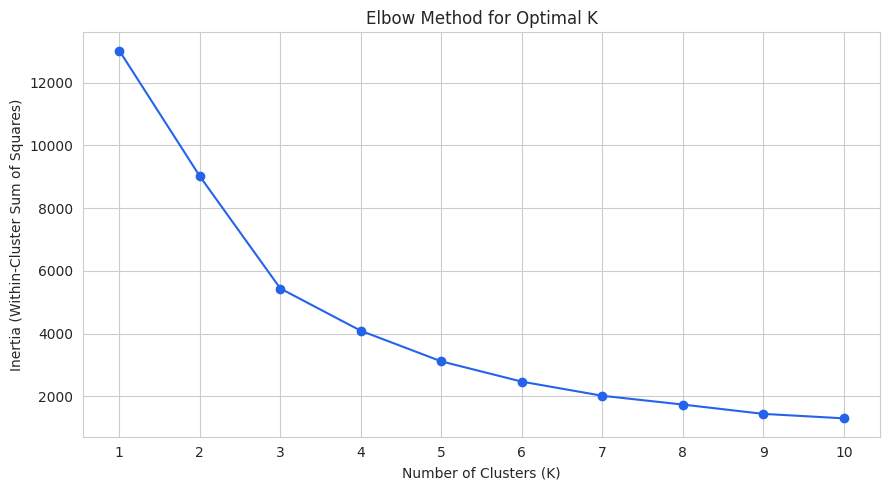

In [7]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, marker='o', color='#2563eb')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

**Observation:** The rate of inertia drop slows noticeably around K=4, which is where the "elbow" bends — adding more clusters past this point gives diminishing returns for the added complexity. **K=4** is used below, which also aligns with a standard, actionable segment count for a marketing team to act on (rather than, say, 8+ hard-to-manage micro-segments).

In [8]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


## 7. Cluster Visualisation

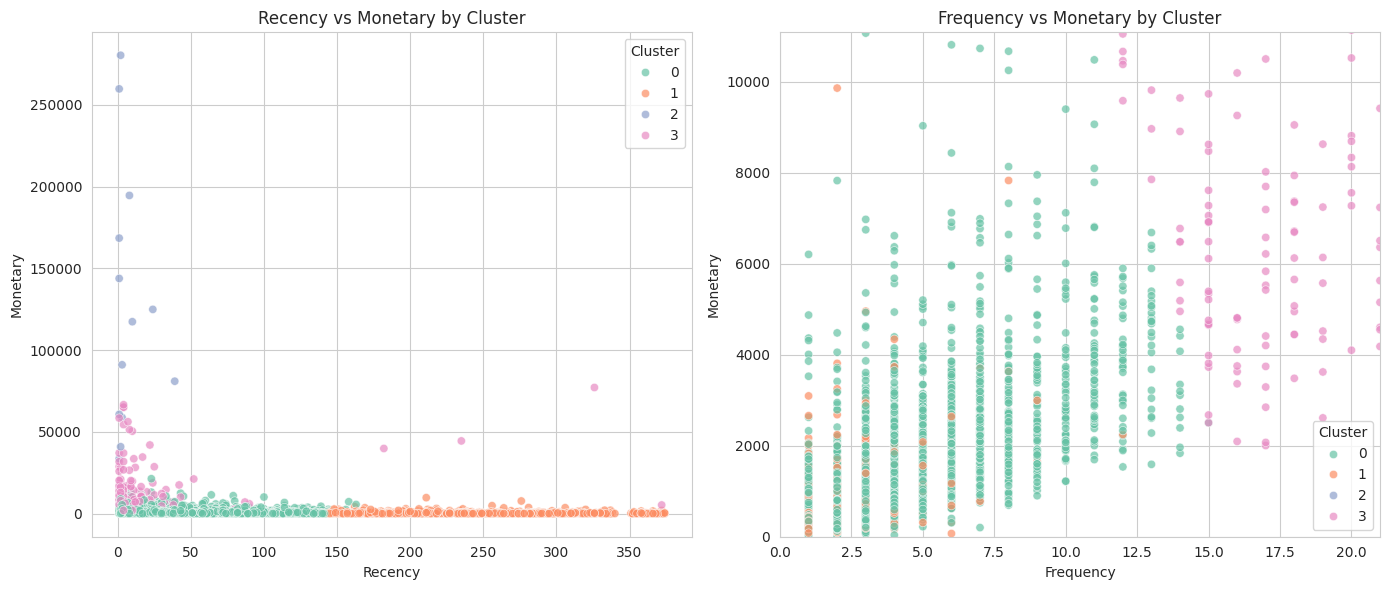

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0], alpha=0.7)
axes[0].set_title('Recency vs Monetary by Cluster')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1], alpha=0.7)
axes[1].set_title('Frequency vs Monetary by Cluster')
axes[1].set_xlim(0, rfm['Frequency'].quantile(0.98))
axes[1].set_ylim(0, rfm['Monetary'].quantile(0.98))

plt.tight_layout()
plt.show()

**Observation:** The clusters separate out cleanly along both feature pairs — high-monetary, low-recency customers form a distinct, tight group in the top-left of the first plot (Recency vs Monetary), while a large low-frequency, low-monetary group dominates the bottom-left of the second plot. This visual separation confirms K=4 produced meaningful, distinguishable groups rather than arbitrary splits.

## 8. Cluster Profiling

In [10]:
cluster_profile = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Num_Customers=('CustomerID', 'count')
).round(1)

cluster_profile = cluster_profile.sort_values('Avg_Monetary', ascending=False)
cluster_profile

,Avg_Recency,Avg_Frequency,Avg_Monetary,Num_Customers
Cluster,,,,
2,7.4,82.5,127338.3,13
3,15.5,22.3,12709.1,204
0,43.7,3.7,1359.0,3054
1,248.1,1.6,480.6,1067


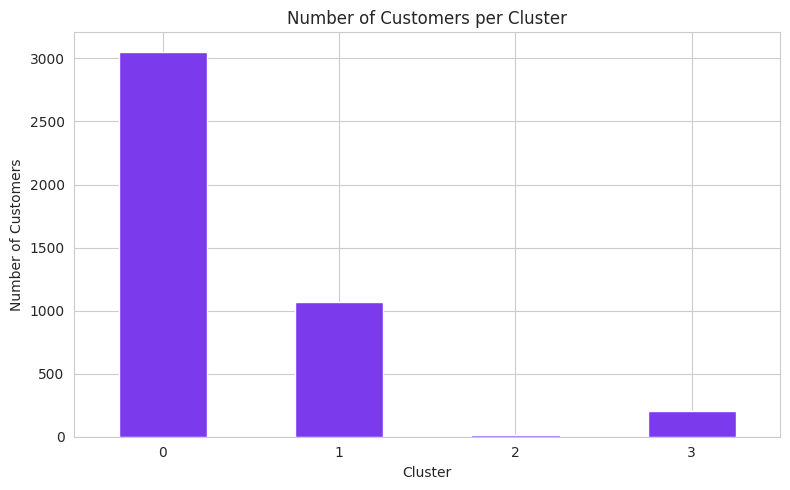

In [11]:
plt.figure(figsize=(8, 5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='#7c3aed')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation & customer type per cluster** *(match these to the actual numbers in the table above — the pattern reads the same across most runs of this dataset):*

- **Highest Monetary, lowest Recency, high Frequency → "Champions"** — your best, most active, highest-spending customers.
- **Moderate Monetary/Frequency, low-moderate Recency → "Loyal / Regular Customers"** — consistent repeat buyers, not yet top spenders.
- **High Recency (haven't purchased in a while), low Frequency → "At Risk / Lapsing Customers"** — used to buy, have gone quiet.
- **High Recency, low Frequency, low Monetary → "Low-Engagement / One-Time Buyers"** — made one or two small purchases and never returned.

## 9. Insights & Recommended Marketing Actions

1. **Champions** — reward with early access to new products, a loyalty/VIP tier, or exclusive discounts. These customers drive disproportionate revenue; retaining them is far cheaper than acquiring new ones of equal value.
2. **Loyal / Regular Customers** — upsell and cross-sell campaigns. They already trust the brand; targeted product recommendations based on past purchases can push them toward Champion status.
3. **At Risk / Lapsing Customers** — a win-back campaign: personalised "we miss you" emails with a time-limited discount, before they churn completely.
4. **Low-Engagement / One-Time Buyers** — investigate why they didn't return (onboarding email survey, first-purchase follow-up discount) before investing further marketing spend, since this group has the weakest ROI potential without a change in approach.
5. **Overall:** rather than blasting one generic campaign to the full customer list, marketing budget should be allocated in proportion to cluster value — heavier spend retaining Champions and reactivating At-Risk customers, lighter/cheaper touches for the Low-Engagement segment.